Saving insurance.csv to insurance (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open insurance.zip, insurance.zip.zip or insurance.zip.ZIP.
Dataset Shape: (1338, 7)

MULTI

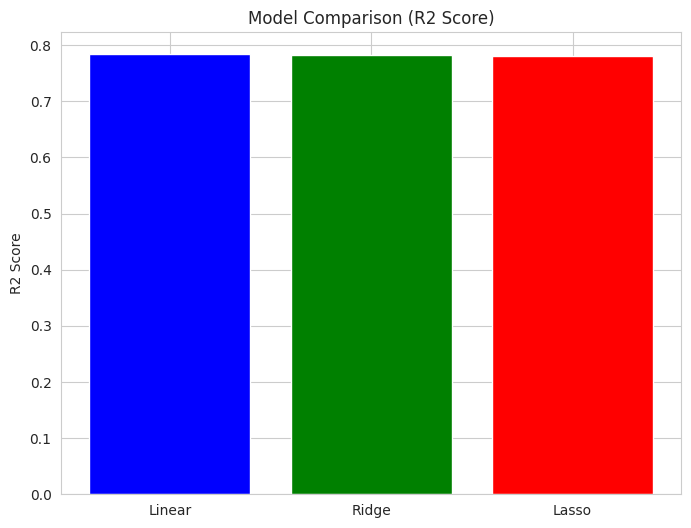

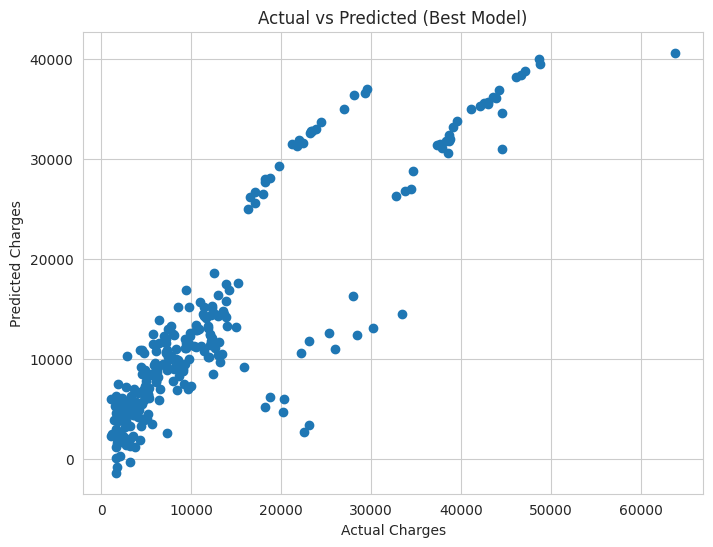

In [1]:
# ==========================================================
# MULTIPLE REGRESSION, RIDGE & LASSO REGRESSION
# Medical Insurance Cost Prediction
# ==========================================================

# -------------------------------
# STEP 1: Install & Setup Kaggle
# -------------------------------
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mirichoi0218/insurance
!unzip insurance.zip


# -------------------------------
# STEP 2: Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,6)


# -------------------------------
# STEP 3: Load Dataset
# -------------------------------
df = pd.read_csv("insurance.csv")

print("Dataset Shape:", df.shape)
df.head()


# -------------------------------
# STEP 4: Data Preprocessing
# -------------------------------

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop("charges", axis=1)
y = df["charges"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================================
# 1️⃣ MULTIPLE LINEAR REGRESSION
# ==========================================================
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

print("\nMULTIPLE LINEAR REGRESSION")
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("R2 Score:", r2_score(y_test, y_pred_lin))


# ==========================================================
# 2️⃣ RIDGE REGRESSION (L2 Regularization)
# ==========================================================
ridge = Ridge()

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print("\nRIDGE REGRESSION")
print("Best Alpha:", ridge_cv.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


# ==========================================================
# 3️⃣ LASSO REGRESSION (L1 Regularization)
# ==========================================================
lasso = Lasso(max_iter=10000)

lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

print("\nLASSO REGRESSION")
print("Best Alpha:", lasso_cv.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


# ==========================================================
# COMPARISON VISUALIZATION
# ==========================================================
models = ['Linear', 'Ridge', 'Lasso']
r2_scores = [
    r2_score(y_test, y_pred_lin),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.bar(models, r2_scores, color=['blue','green','red'])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()


# Actual vs Predicted (Best Model)
best_model_pred = y_pred_ridge  # usually Ridge performs best here

plt.scatter(y_test, best_model_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Best Model)")
plt.show()